# Task 3: Car Price Prediction with Machine Learning
Predict used-car selling price from brand, age, mileage, fuel type and transmission.

**Dataset:** Vehicle dataset from CarDekho (`CAR_DETAILS_FROM_CAR_DEKHO.csv`, Kaggle). Update `FILE` below if your filename differs.

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_style('whitegrid')
FILE = 'CAR DETAILS FROM CAR DEKHO.csv'

## 1. Load data

In [6]:
df = pd.read_csv(FILE)
print(df.shape)
df.head()

(4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [7]:
!ls

'CAR DETAILS FROM CAR DEKHO.csv'   sample_data


## 2. Data cleaning

In [8]:
print('Nulls:\n', df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
df = df.dropna().drop_duplicates().reset_index(drop=True)

# Remove extreme outliers (top 1% prices, e.g. luxury cars) so they don't dominate the model
cap = df['selling_price'].quantile(0.99)
df = df[df['selling_price'] <= cap].reset_index(drop=True)
print('Rows after cleaning:', len(df), '| price cap:', int(cap))

# Make categorical text consistent (e.g. "Petrol" vs "petrol")
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()
print(df['fuel'].value_counts())
print(df['transmission'].value_counts())

Nulls:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64
Duplicates: 763
Rows after cleaning: 3542 | price cap: 2675000
fuel
diesel      1769
petrol      1713
cng           37
lpg           22
electric       1
Name: count, dtype: int64
transmission
manual       3265
automatic     277
Name: count, dtype: int64


## 3. Feature engineering: car age and brand

In [9]:
current_year = pd.Timestamp.now().year
df['car_age'] = current_year - df['year']
df['brand'] = df['name'].str.split().str[0]      # first word of name = brand
# Keep only brands with enough samples so one-hot stays manageable
top = df['brand'].value_counts()
df['brand'] = df['brand'].where(df['brand'].isin(top[top >= 20].index), 'other')
df[['name', 'brand', 'year', 'car_age']].head()

,name,brand,year,car_age
0,maruti 800 ac,maruti,2007,19
1,maruti wagon r lxi minor,maruti,2007,19
2,hyundai verna 1.6 sx,hyundai,2012,14
3,datsun redigo t option,datsun,2017,9
4,honda amaze vx i-dtec,honda,2014,12


## 4. Exploratory data analysis

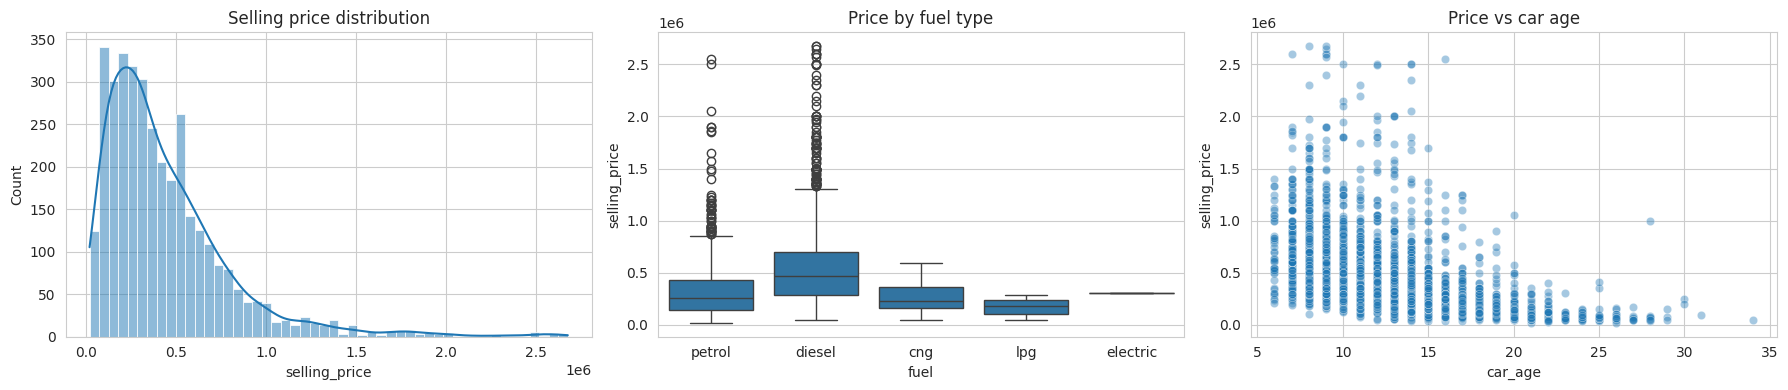

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df['selling_price'], bins=50, kde=True, ax=ax[0]); ax[0].set_title('Selling price distribution')
sns.boxplot(x='fuel', y='selling_price', data=df, ax=ax[1]); ax[1].set_title('Price by fuel type')
sns.scatterplot(x='car_age', y='selling_price', data=df, alpha=0.4, ax=ax[2]); ax[2].set_title('Price vs car age')
plt.tight_layout(); plt.show()

## 5. Encode categorical variables (One-Hot)

In [11]:
data = df.drop(columns=['name', 'year'])
data = pd.get_dummies(data, columns=['brand', 'fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)
data.shape

(3542, 29)

## 6. Correlation heatmap
Shown for the numeric columns plus the strongest encoded features.

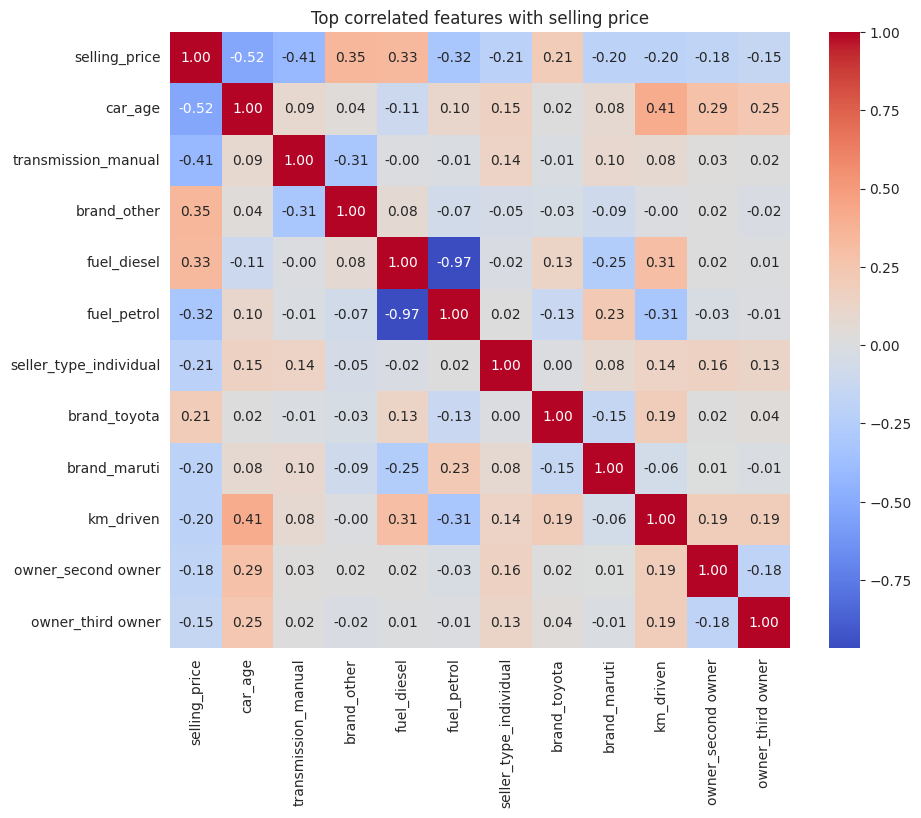

In [12]:
corr = data.corr()
top_cols = corr['selling_price'].abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(10, 8))
sns.heatmap(data[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Top correlated features with selling price'); plt.show()

## 7. Train/test split

In [13]:
X = data.drop(columns='selling_price')
y = data['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(2833, 28) (709, 28)


## 8. Train models

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}
for m in models.values():
    m.fit(X_train, y_train)

## 9. Evaluate (MAE, RMSE, R²)

In [15]:
rows = []
for name, m in models.items():
    p = m.predict(X_test)
    rows.append({'Model': name, 'MAE': mean_absolute_error(y_test, p),
                 'RMSE': np.sqrt(mean_squared_error(y_test, p)), 'R2': r2_score(y_test, p)})
results = pd.DataFrame(rows).set_index('Model')
results.round(3)

,MAE,RMSE,R2
Model,,,
Linear Regression,146415.394,215875.819,0.650
Random Forest,127269.208,203591.993,0.689
Gradient Boosting,124275.670,192747.364,0.721


## 10. Feature importance for the best model

Best model: Gradient Boosting


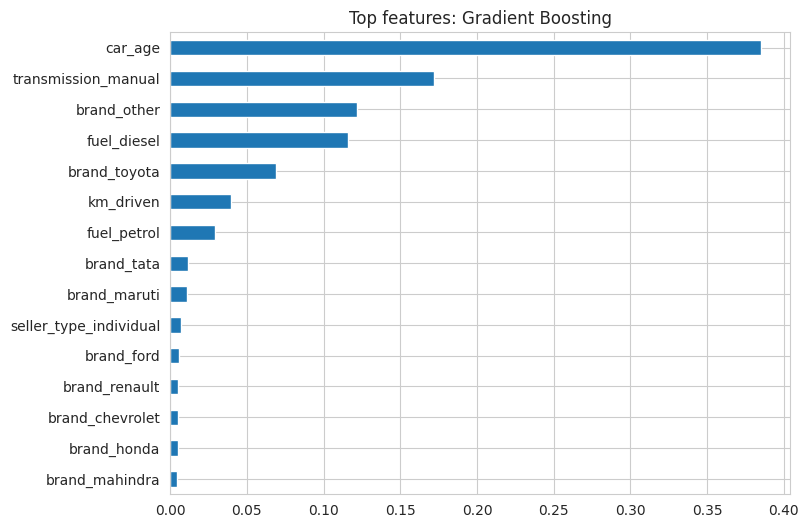

In [16]:
best_name = results['R2'].idxmax()
best = models[best_name]
print('Best model:', best_name)
if hasattr(best, 'feature_importances_'):
    imp = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
else:
    imp = pd.Series(best.coef_, index=X.columns).abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
imp[::-1].plot(kind='barh'); plt.title(f'Top features: {best_name}'); plt.show()

## Summary
- **Data cleaning:** Removed duplicate rows, made text values consistent (for example "Petrol" and "petrol"), and removed the top 1% most expensive cars (luxury outliers) so they would not distort the model.
- **Feature engineering:** Created `car_age` from the year column and extracted the car `brand` from the name column. Categorical columns were encoded with One-Hot Encoding.
- **Models trained:** Linear Regression, Random Forest and Gradient Boosting.
- **Best model:** Gradient Boosting performed best with an R² of about 0.72 (MAE about 124,000 and RMSE about 193,000), ahead of Random Forest (R² about 0.69) and Linear Regression (R² about 0.65).
- **Most important features:** Car age had the biggest effect on the selling price, followed by transmission type (manual or automatic), fuel type (diesel) and brand. Kilometres driven also has an effect, but a smaller one.
- **Conclusion:** Newer cars with automatic transmission sell for higher prices, and older cars sell for less. The model could be improved further with more features such as engine size, mileage and car condition.